In [1]:
import pandas as pd


In [2]:
res.columns

NameError: name 'res' is not defined

In [13]:
res = pd.read_csv("./output/support_boost_exp5_on_oss/pipeline_results.csv")
# /BTP/BtechProject/FocusedRetriever/output/support_boost_exp4_new_scoring_function/pipeline_results.csv
rec = res["recall@20"]
cnt = res["total_answers"]
zero_recall = 0 
full_recall = 0 
partial_recall = 0 
length = len(rec) 


for recall in rec :
    if recall == 0 :
        zero_recall += 1 
    elif recall == 1 :
        full_recall+= 1 
    else :
        partial_recall += 1 

print(" zero recall     :",zero_recall/length,"\n parital recall  :" ,partial_recall/length, "\n full recall     :" ,full_recall/length) 

 zero recall     : 0.3761467889908257 
 parital recall  : 0.09174311926605505 
 full recall     : 0.5321100917431193


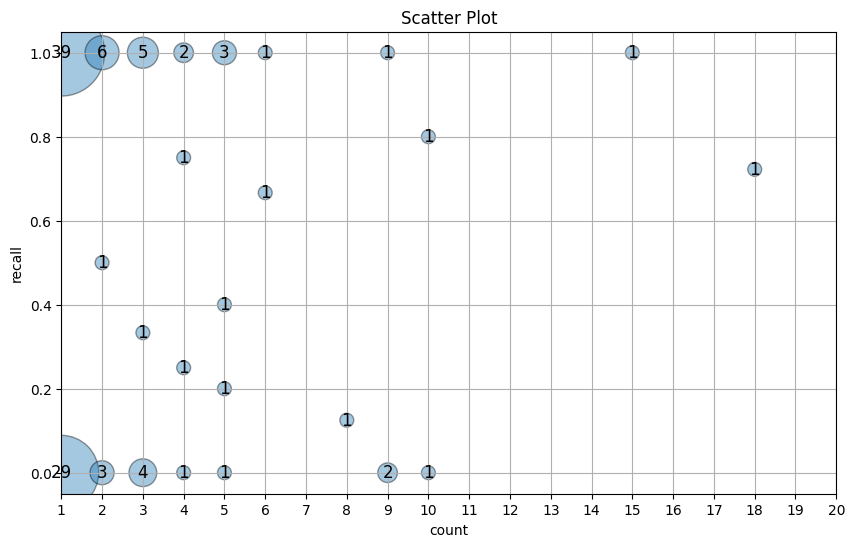

In [14]:


import pandas as pd
import matplotlib.pyplot as plt

# Suppose your series are:
# x = pd.Series(...)
# y = pd.Series(...)

df = pd.DataFrame({'x': cnt, 'y': rec})
plt.figure(figsize=(10, 6))

# Count frequency of each (x, y) pair
freq = df.value_counts().reset_index(name='count')
# Add labels for each bubble
for _, row in freq.iterrows():
    plt.text(row['x'], row['y'], str(int(row['count'])),
             fontsize=12, ha='center', va='center', color='black' )

# Scatter plot with size proportional to frequency
plt.scatter(freq['x'], freq['y'], s=freq['count'] * 100, alpha=0.4, edgecolors='k')
plt.xlabel("count")
plt.ylabel("recall")
plt.title("Scatter Plot")
plt.grid(True)
plt.xlim(1, 20)
plt.xticks(range(1, 21))
plt.show()


#  zero recall     : 0.2730627306273063 
#  parital recall  : 0.05904059040590406 
#  full recall     : 0.6678966789667896

In [8]:
import os
import pandas as pd

def analyze_pipeline_results(verbose=True):
    # Collect all CSV files in cwd and ./output/
    search_dirs = [os.getcwd(), os.path.join(os.getcwd(), "output")]
    csv_files = []

    for d in search_dirs:
        for root, _, files in os.walk(d):
            for f in files:
                if f.endswith(".csv") and f.endswith("pipeline_results.csv"):
                    csv_files.append(os.path.join(root, f))

    if not csv_files:
        print("No *_pipeline_results.csv files found.")
        return

    for path in csv_files:
        try:
            res = pd.read_csv(path)
            if "recall@20" not in res.columns:
                if verbose:
                    print(f"⚠️ Skipping {path} (no recall@20 column).")
                continue

            rec = res["recall@20"].fillna(0)
            length = len(rec)
            zero_recall = (rec == 0).sum()
            full_recall = (rec == 1).sum()
            partial_recall = length - zero_recall - full_recall

            avg_recall = rec.mean()
            median_recall = rec.median()
            min_recall = rec.min()
            max_recall = rec.max()
            std_recall = rec.std()

            print(f"\n📄 File: {path}")
            print(f"Total samples: {length}")
            print(f"Zero recall (0.0): {zero_recall} ({zero_recall/length:.2%})")
            print(f"Full recall (1.0): {full_recall} ({full_recall/length:.2%})")
            print(f"Partial recall (0<r<1): {partial_recall} ({partial_recall/length:.2%})")
            print(f"Average recall: {avg_recall:.4f}")
            print(f"Median recall: {median_recall:.4f}")
            print(f"Min recall: {min_recall:.4f}, Max recall: {max_recall:.4f}, Std: {std_recall:.4f}")

            # Extra descriptive stats on partial recall
            partial_values = rec[(rec > 0) & (rec < 1)]
            if len(partial_values) > 0:
                print(f"  └─ Partial recall range: {partial_values.min():.4f} – {partial_values.max():.4f}")
                print(f"  └─ Partial recall mean: {partial_values.mean():.4f}, std: {partial_values.std():.4f}")
                quantiles = partial_values.quantile([0.25, 0.5, 0.75])
                print(f"  └─ Partial recall quartiles: Q1={quantiles[0.25]:.4f}, Q2={quantiles[0.5]:.4f}, Q3={quantiles[0.75]:.4f}")

        except Exception as e:
            print(f"❌ Error reading {path}: {e}")

# Run it
analyze_pipeline_results()


⚠️ Skipping /home/sarthak/BTP/BTechProject/output/exp1_pipeline_results.csv (no recall@20 column).

📄 File: /home/sarthak/BTP/BTechProject/output/considering_support_to_update_weights_temp/pipeline_results.csv
Total samples: 284
Zero recall (0.0): 153 (53.87%)
Full recall (1.0): 109 (38.38%)
Partial recall (0<r<1): 22 (7.75%)
Average recall: 0.4259
Median recall: 0.0000
Min recall: 0.0000, Max recall: 1.0000, Std: 0.4794
  └─ Partial recall range: 0.1111 – 0.9000
  └─ Partial recall mean: 0.5433, std: 0.2234
  └─ Partial recall quartiles: Q1=0.4250, Q2=0.5000, Q3=0.7083

📄 File: /home/sarthak/BTP/BTechProject/output/support_boost_exp3/pipeline_results.csv
Total samples: 271
Zero recall (0.0): 109 (40.22%)
Full recall (1.0): 132 (48.71%)
Partial recall (0<r<1): 30 (11.07%)
Average recall: 0.5418
Median recall: 0.7692
Min recall: 0.0000, Max recall: 1.0000, Std: 0.4767
  └─ Partial recall range: 0.0714 – 0.9000
  └─ Partial recall mean: 0.4940, std: 0.2332
  └─ Partial recall quartiles: 